<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/sleep/solved/07_lognormal_varying_intercept_slope.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sleep deprivation 7 — Hierarchical lognormal regression

Combine the lognormal likelihood with participant-specific intercepts and slopes.

## Setup

This course pins PyMC and the modular ArviZ packages for reproducibility because their APIs can change across major versions.

In [1]:
%pip install -q \
    "pandas==2.2.3" \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1"

Note: you may need to restart the kernel to use updated packages.


D:\Repositories\BayesShortCourse\tmp\colabenv\Scripts\python.exe: No module named pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import xarray as xr
from pymc.stats.log_density import compute_log_density
import pymc as pm
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs

RANDOM_SEED = 20260924
azp.style.use("arviz-variat")

print("PyMC:", pm.__version__)
print("arviz-base:", azb.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

g++ not available, if using conda: `conda install gxx`


PyMC: 6.3.2
arviz-base: 1.3.0
arviz-plots: 1.3.1
arviz-stats: 1.3.2


## Data

The original study contains two adaptation/training days followed by a baseline measurement and then seven nights of severe sleep restriction. You can read about the original study here: [Belenky J Sleep Res. 2003](https://doi.org/10.1046/j.1365-2869.2003.00337.x)

Following the chapter, we drop original days 0–1 and subtract 2 from the remaining day number. Therefore **`Days = 0` is the baseline measurement before sleep deprivation begins**.

That zero point is scientifically meaningful, so every model in this sequence keeps `Days` on its natural scale (no centering). The intercept prior is therefore a prior on baseline reaction time rather than reaction time at the average deprivation day.

In [3]:
DATA_URL = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/lme4/sleepstudy.csv"

sleep = pd.read_csv(DATA_URL).drop(columns="rownames")
sleep = sleep.loc[sleep["Days"] >= 2].copy()
sleep["Days"] = sleep["Days"] - 2
sleep["Subject"] = sleep["Subject"].astype(str)
sleep = sleep.reset_index(drop=True)

print(f"{sleep['Subject'].nunique()} participants, {len(sleep)} observations")
print(f"Days: {sleep['Days'].min()} to {sleep['Days'].max()}")
sleep.head()

18 participants, 144 observations
Days: 0 to 7


,Reaction,Days,Subject
0,250.8006,0,308
1,321.4398,1,308
2,356.8519,2,308
3,414.6901,3,308
4,382.2038,4,308


In [4]:
# Plotting helpers (presentation only). Every plot uses the golf-notebook grammar:
# orange mean line, blue 50% and 90% HDI bands, black observed points.
DRAW_COLOR = "#12505e"  # darker shade of the band colour C0
LM_VISUALS = {
    "pe_line": {"color": "C1"},
    "ci_band": {"color": "C0"},
    "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3, "s": 10},
}
PARTICIPANT_DAY = xr.Coordinates.from_pandas_multiindex(
    pd.MultiIndex.from_frame(sleep[["Subject", "Days"]], names=["participant", "day"]),
    "obs_id",
)

def add_interval_legend(target, line_label="mean", draws_label=None):
    """Compact one-row legend above an axis or above a whole panel grid."""
    handles = [
        Line2D([0], [0], color="C1", lw=1.6, label=line_label),
        Patch(facecolor="C0", alpha=0.9, label="50% HDI"),
        Patch(facecolor="C0", alpha=0.28, label="90% HDI"),
    ]
    if draws_label:
        handles.append(Line2D([0], [0], color=DRAW_COLOR, lw=0.9, label=draws_label))
    handles.append(Line2D([0], [0], marker="o", linestyle="none", color="black",
                          markersize=4.5, label="observed"))
    style = dict(ncols=len(handles), fontsize=8, handlelength=1.4, handletextpad=0.45,
                 columnspacing=0.9, frameon=False)
    if isinstance(target, plt.Figure):
        target.legend(handles=handles, loc="outside upper left", **style)
    else:
        target.legend(handles=handles, loc="lower left", bbox_to_anchor=(0, 1.01),
                      borderaxespad=0, **style)

def plot_population(dt, var, group="posterior"):
    """Single-panel trend of `var` against days, with all 144 raw observations."""
    pc = azp.plot_lm(
        dt, x="days", y=var, y_obs="Reaction", group=group, plot_dim="obs_id",
        ci_prob=(0.50, 0.90), ci_kind="hdi", point_estimate="mean", smooth=False,
        figure_kwargs={"figsize": (7, 4)}, visuals=LM_VISUALS,
    )
    ax = plt.gca()
    ax.set(xlabel="Days of sleep deprivation", ylabel="Reaction time (ms)")
    add_interval_legend(ax)
    return pc

def plot_participants(dt, group, var):
    """One panel per participant: bands for `var` against days, with that participant's data."""
    def reshape(ds):
        return ds.assign_coords(PARTICIPANT_DAY).unstack("obs_id")
    panels = xr.DataTree.from_dict({
        group: reshape(dt[group].to_dataset()),
        "observed_data": reshape(dt["observed_data"].to_dataset()),
        "constant_data": reshape(dt["constant_data"].to_dataset()),
    })
    pc = azp.plot_lm(
        panels, x="days", y=var, y_obs="Reaction", group=group, plot_dim="day",
        ci_prob=(0.50, 0.90), ci_kind="hdi", point_estimate="mean", smooth=False,
        cols=["participant"], col_wrap=6,
        figure_kwargs={"figsize": (11, 5.5), "sharex": True, "sharey": True},
        visuals={**LM_VISUALS, "xlabel": False, "ylabel": False},
    )
    fig = pc.viz["figure"].item()
    fig.supxlabel("Days of sleep deprivation")
    fig.supylabel("Reaction time (ms)")
    add_interval_legend(fig)
    return pc

In [5]:
participants = sorted(sleep["Subject"].unique(), key=int)
participant_idx = sleep["Subject"].map({p: i for i, p in enumerate(participants)}).to_numpy()

## 7.1 Hierarchy on a multiplicative scale

How do participant-specific baseline and deprivation effects behave when the model is multiplicative on the reaction-time scale?

The linear predictor is now on the log reaction-time scale. Participant deviations therefore act multiplicatively after transforming back to milliseconds. As in notebook 5, we use independent group-level priors rather than a joint LKJ-correlated prior.

In [6]:
coords = {"obs_id": np.arange(len(sleep)), "participant": participants}

with pm.Model(coords=coords) as model:
    days = pm.Data("days", sleep["Days"].to_numpy(), dims="obs_id")
    pidx = pm.Data("participant_idx", participant_idx, dims="obs_id")

    intercept = pm.Normal("intercept", mu=5, sigma=0.55)
    slope = pm.Normal("slope", mu=0, sigma=0.20)
    sigma = pm.Exponential("sigma", lam=6)

    participant_intercept_sd = pm.Exponential("participant_intercept_sd", lam=6)
    participant_intercept_z = pm.Normal("participant_intercept_z", 0, 1, dims="participant")
    participant_intercept = pm.Deterministic(
        "participant_intercept",
        participant_intercept_sd * participant_intercept_z,
        dims="participant",
    )

    participant_slope_sd = pm.Exponential("participant_slope_sd", lam=10)
    participant_slope_z = pm.Normal("participant_slope_z", 0, 1, dims="participant")
    participant_slope = pm.Deterministic(
        "participant_slope",
        participant_slope_sd * participant_slope_z,
        dims="participant",
    )

    population_mu = pm.Deterministic(
        "population_mu", intercept + slope * days, dims="obs_id"
    )
    mu = pm.Deterministic(
        "mu",
        population_mu
        + participant_intercept[pidx]
        + participant_slope[pidx] * days,
        dims="obs_id",
    )
    mean_rt = pm.Deterministic(
        "mean_rt", pm.math.exp(mu + sigma**2 / 2), dims="obs_id"
    )
    population_mean_rt = pm.Deterministic(
        "population_mean_rt", pm.math.exp(population_mu + sigma**2 / 2), dims="obs_id"
    )

    pm.LogNormal(
        "Reaction",
        mu=mu,
        sigma=sigma,
        observed=sleep["Reaction"].to_numpy(),
        dims="obs_id",
    )

Before fitting, ask what reaction times the priors make plausible. Each panel is one participant. The bands are the prior predictive distribution of a single new reaction-time measurement on each day. The black points are that participant's data, shown only as a reference: they do not condition the prior.

Sampling: [Reaction, intercept, participant_intercept_sd, participant_intercept_z, participant_slope_sd, participant_slope_z, sigma, slope]


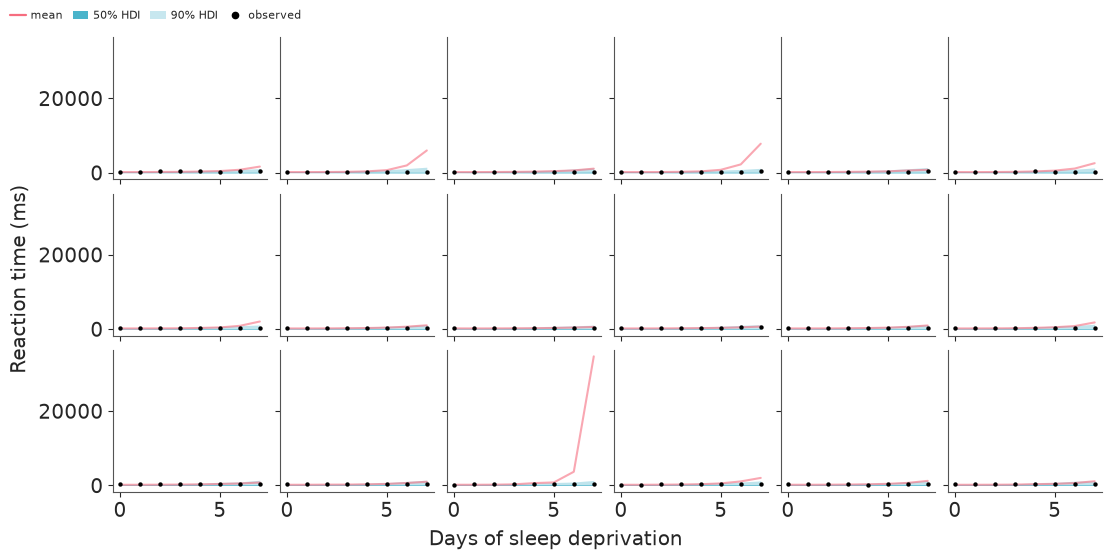

In [7]:
with model:
    prior = pm.sample_prior_predictive(
        draws=500, var_names=["Reaction"], random_seed=RANDOM_SEED
    )

plot_participants(prior, "prior_predictive", "Reaction")
plt.show()

## 7.2 Heterogeneity under the lognormal model

How much participant-to-participant heterogeneity does the hierarchical lognormal model estimate?

Do not interpret the fit until the sampler diagnostics are acceptable: no divergences, R-hat ≤ 1.01, and bulk and tail ESS in the hundreds or more.

In [8]:
with model:
    idata = pm.sample(
        draws=1000, tune=1500, chains=4, target_accept=0.95, random_seed=RANDOM_SEED
    )

print("Divergences:", int(idata["sample_stats"]["diverging"].sum().item()))
azs.summary(
    idata, var_names=["intercept", "slope", "sigma", "participant_intercept_sd", "participant_slope_sd"],
    ci_prob=0.90, ci_kind="hdi", round_to=2,
)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [intercept, slope, sigma, participant_intercept_sd, participant_intercept_z, participant_slope_sd, participant_slope_z]


D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 18 seconds.


Divergences: 0


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,5.59,0.03,5.53,5.64,1501.33,1802.53,1.01,0.0,0.0
slope,0.04,0.01,0.03,0.05,1944.84,2307.17,1.00,0.0,0.0
sigma,0.08,0.01,0.07,0.09,3442.69,2612.50,1.00,0.0,0.0
participant_intercept_sd,0.13,0.03,0.08,0.17,1628.76,1842.13,1.00,0.0,0.0
participant_slope_sd,0.02,0.01,0.01,0.03,1771.55,2322.79,1.00,0.0,0.0


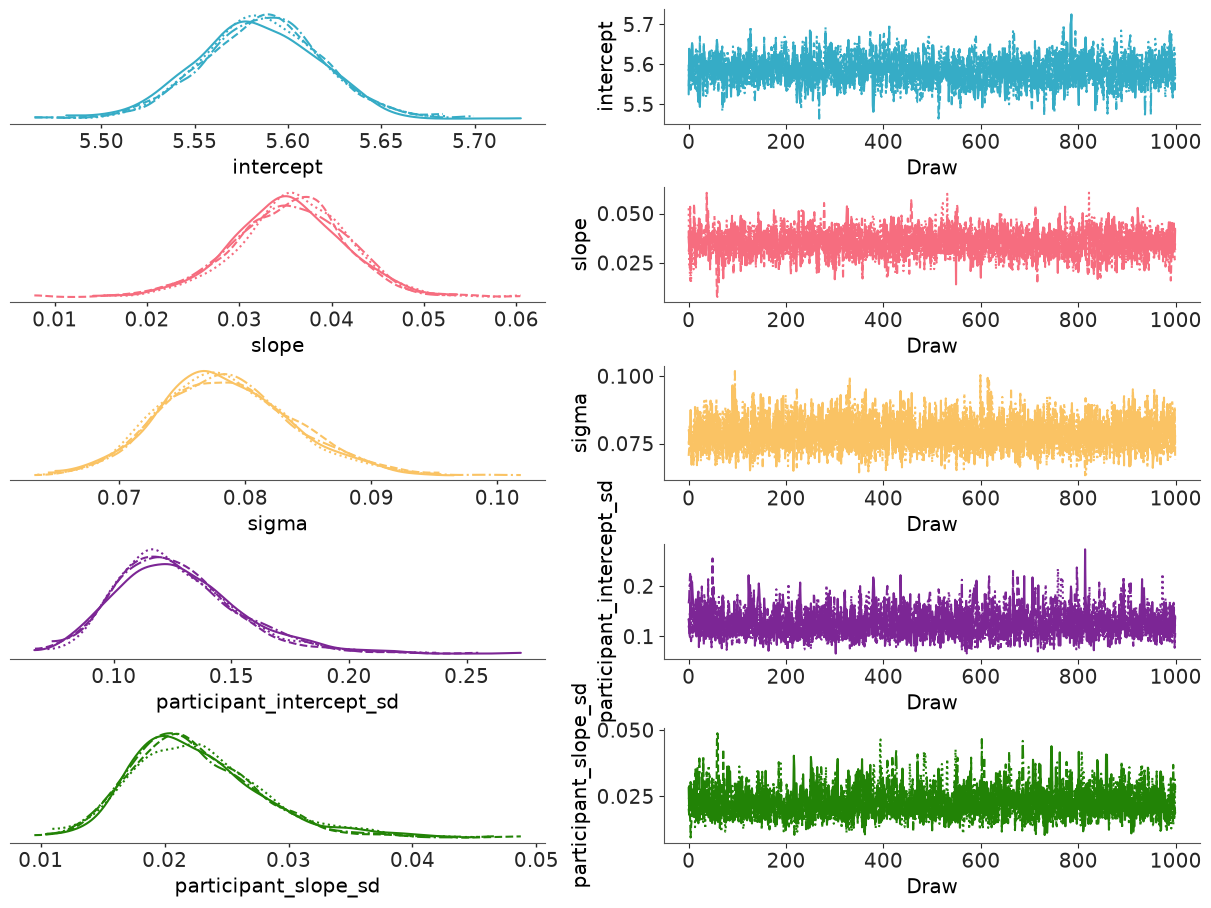

In [9]:
azp.plot_trace_dist(idata, var_names=["intercept", "slope", "sigma", "participant_intercept_sd", "participant_slope_sd"]);

This plot shows posterior uncertainty in the expected reaction time (on the millisecond scale) of a *typical* participant. It does not include between-participant or measurement-to-measurement variation.

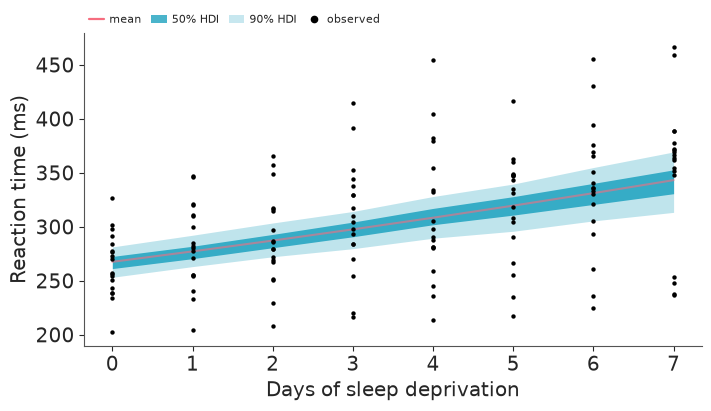

In [10]:
plot_population(idata, "population_mean_rt")
plt.show()

Each panel shows posterior uncertainty in that participant's expected reaction time. These are mean trajectories, not new measurements. The next plot adds measurement variation.

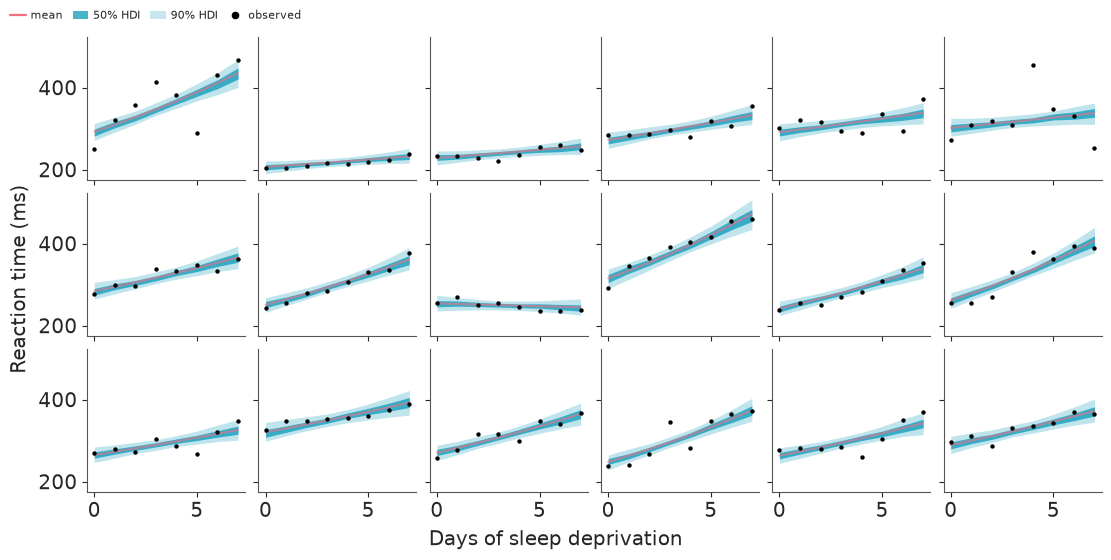

In [11]:
plot_participants(idata, "posterior", "mean_rt")
plt.show()

## 7.3 Remaining distributional mismatch

What aspects of the reaction-time distribution remain poorly captured by a hierarchical lognormal model?

Now generate new reaction times from the fitted model. The layout is the same as in the prior predictive check; the difference is that these predictions are conditioned on the data. The bands are the distribution of a single new measurement for each participant and day.

Sampling: [Reaction]


D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

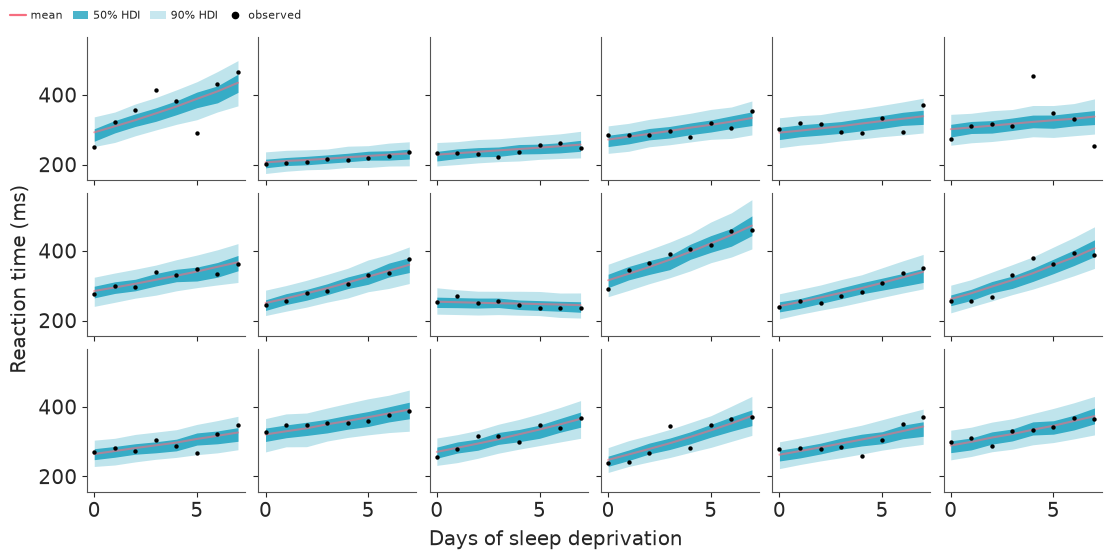

In [12]:
with model:
    pm.sample_posterior_predictive(
        idata, var_names=["Reaction"], extend_inferencedata=True, random_seed=RANDOM_SEED
    )

plot_participants(idata, "posterior_predictive", "Reaction")
plt.show()

The panel plot checks trajectories. This check pools all 144 measurements and asks whether simulated datasets reproduce the overall *shape* of the reaction-time distribution, especially its right tail.

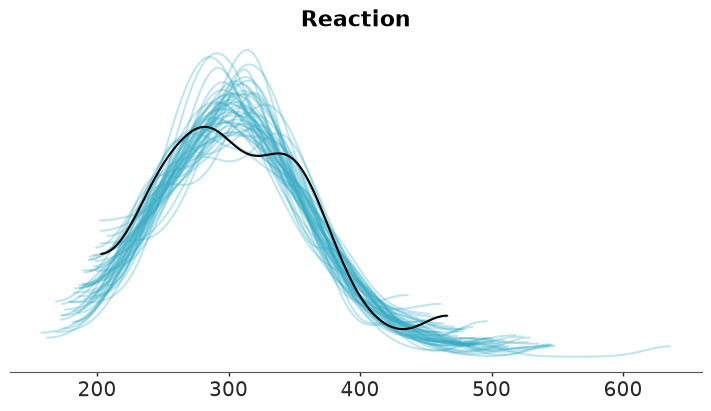

In [13]:
azp.plot_ppc_dist(idata, var_names=["Reaction"], kind="kde", figure_kwargs={"figsize": (7, 4)});

## 7.4 Sensitivity of hierarchical scales

Are the hierarchical lognormal conclusions sensitive to the priors on population and group-level scales?

In [14]:
with model:
    pm.compute_log_likelihood(idata)
    compute_log_density(idata, model=model, kind="prior", extend_inferencedata=True)

vars_for_sensitivity = ["intercept", "slope", "sigma", "participant_intercept_sd", "participant_slope_sd"]
azs.psense_summary(idata, var_names=vars_for_sensitivity)

D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

...

D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

We detected potential issues. For more information on how to interpret the results, please check
https://arviz-devs.github.io/EABM/Chapters/Sensitivity_checks.html#interpreting-sensitivity-diagnostics-summary
or read original paper https://doi.org/10.1007/s11222-023-10366-5


,prior,likelihood,diagnosis
intercept,0.018,0.033,✓
slope,0.017,0.025,✓
sigma,0.025,0.478,✓
participant_intercept_sd,0.403,0.066,potential prior-data conflict
participant_slope_sd,0.379,0.121,potential prior-data conflict


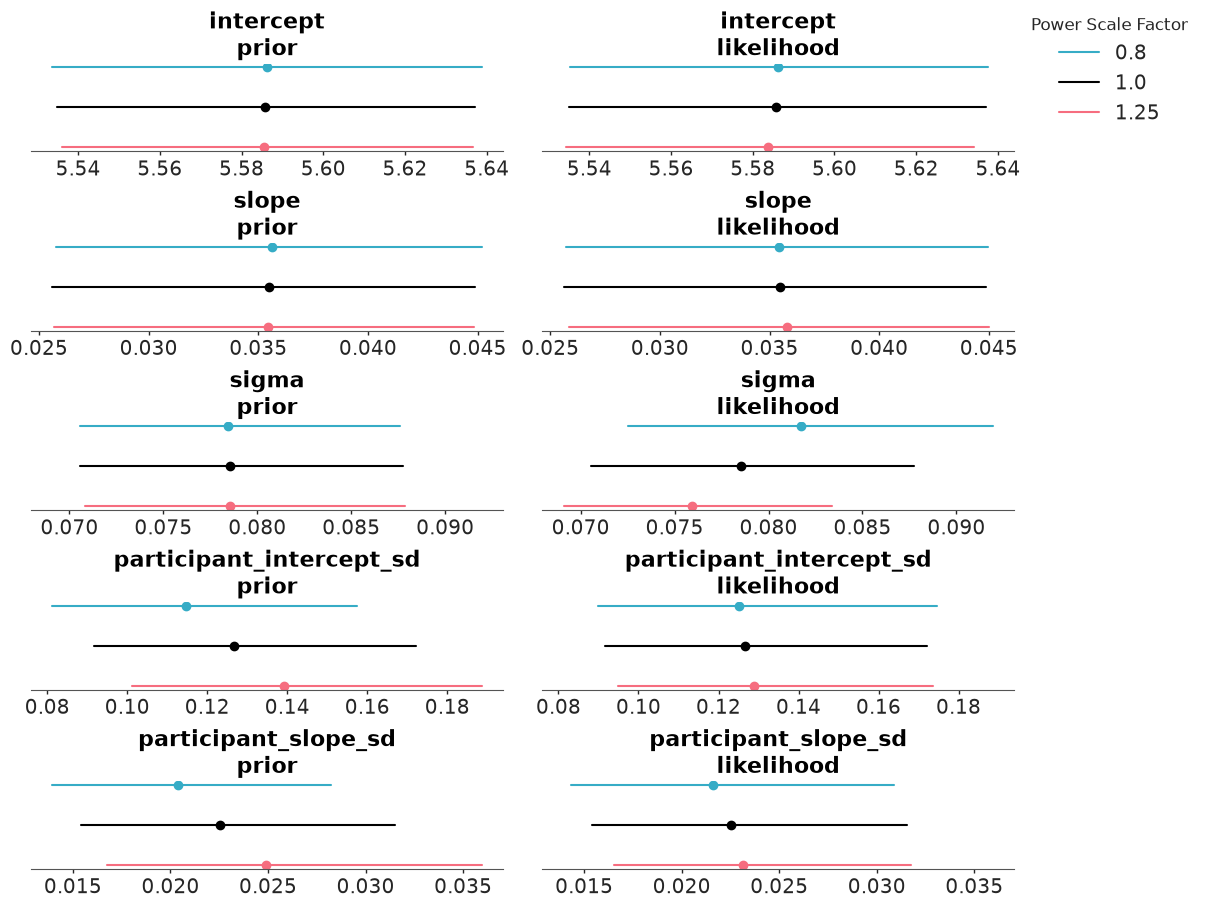

In [15]:
azp.plot_psense_dist(idata, var_names=vars_for_sensitivity, visuals={"dist": False});

The model still assumes one residual log-scale spread for everyone. The next expansion allows residual variability itself to vary by participant.